In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\data\datos_resultados_modularizado\master_hdbscan_v0.csv")

In [5]:
dfg = df.groupby(['source_id','iteraciones']).agg({'ConteoAgrupaciones':'max'}).reset_index()
dfg['probabilidad'] = dfg['ConteoAgrupaciones']/dfg['iteraciones']*0.8

In [6]:
bins = np.arange(0,1.1,0.1)
dfg['prob_bin']  = pd.cut(dfg['probabilidad'], bins, right = False)
resultado = dfg.groupby(["iteraciones", "prob_bin"]).size().reset_index(name="cantidad_estrellas")
matriz = resultado.pivot(index="iteraciones", columns="prob_bin", values="cantidad_estrellas").fillna(0)

C:\Users\nicob\AppData\Local\Temp\ipykernel_19384\3838616687.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resultado = dfg.groupby(["iteraciones", "prob_bin"]).size().reset_index(name="cantidad_estrellas")


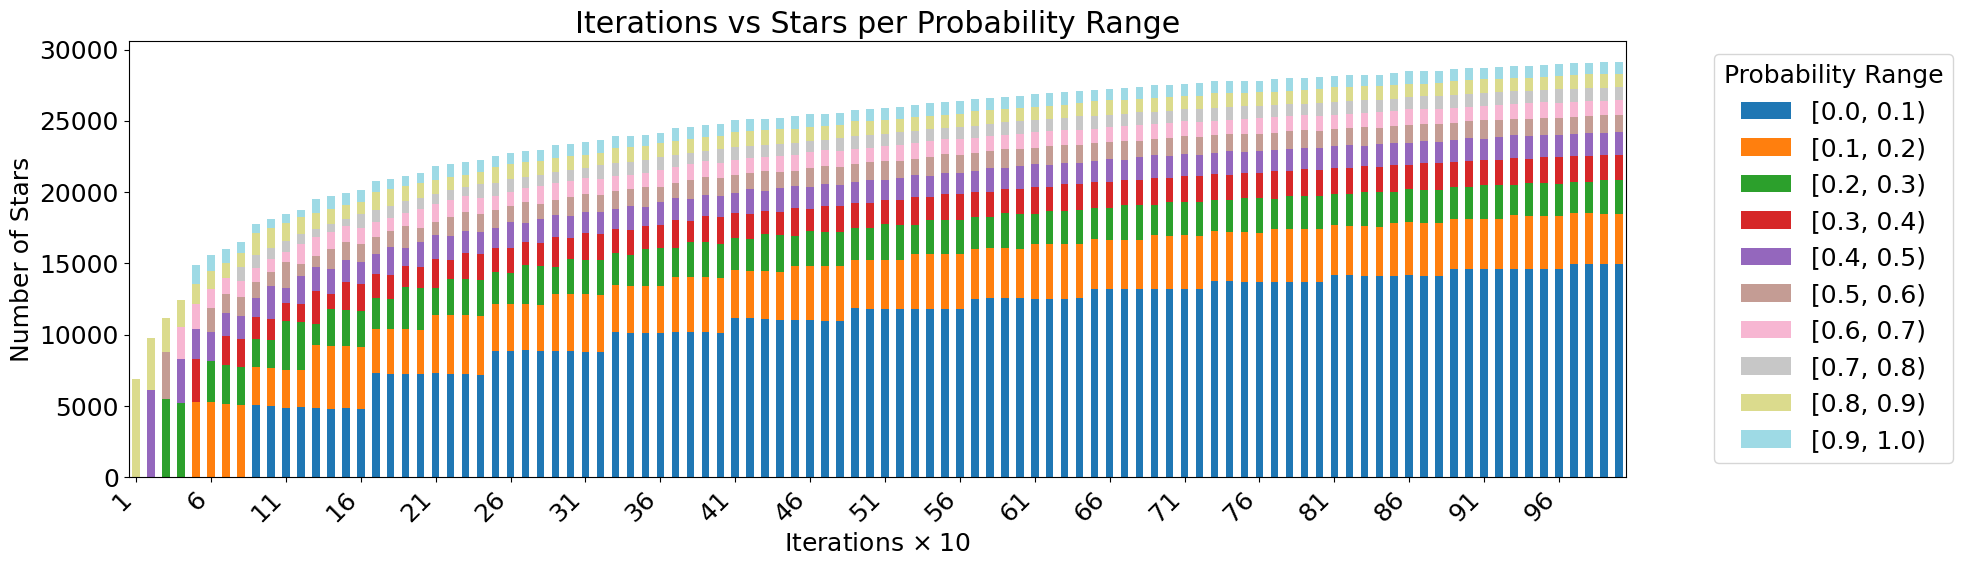

In [17]:
plt.rcParams["font.size"] = 18
matriz.plot(kind="bar", stacked=True, figsize=(20, 6), colormap="tab20")
plt.title("Iterations vs Stars per Probability Range")
plt.xlabel(r"Iterations $\times\;10$")
plt.ylabel("Number of Stars")
plt.legend(title="Probability Range", bbox_to_anchor=(1.05, 1), loc='upper left')
import matplotlib.ticker as ticker
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(5))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [66]:
matriz

prob_bin,"[0.0, 0.1)","[0.1, 0.2)","[0.2, 0.3)","[0.3, 0.4)","[0.4, 0.5)","[0.5, 0.6)","[0.6, 0.7)","[0.7, 0.8)","[0.8, 0.9)","[0.9, 1.0)"
iteraciones,,,,,,,,,,
1,0,0,0,0,0,0,0,0,6907,0
2,0,0,0,0,6105,0,0,0,3643,0
3,0,0,5493,0,0,3309,0,0,2404,0
4,0,0,5234,0,3050,0,2286,0,1847,0
5,0,5303,0,2969,2142,0,1706,0,1469,1318
...,...,...,...,...,...,...,...,...,...,...
96,14606,3691,2299,1873,1529,1224,1051,935,919,840
97,14989,3539,2215,1823,1526,1197,1019,932,979,823
98,14973,3533,2215,1820,1610,1204,1009,922,967,820
